## CRCA for loading $v(s_j,t_i)^+$ into a quantum circuit

In [1]:
%load_ext autoreload
%autoreload 2

from quantum_cva.mc_benchmark.benchmark_utils import (
    simulate_S_legacy,
    price_grid_from_samples,
)

from quantum_cva.cross_validation_utils import SPSAHyperparamCV

import numpy as np
from pathlib import Path
from quantum_cva.crca.crca_circuit import CrcaCircuit
from quantum_cva.circuit_training_tools import save_crca_training
from quantum_cva.circuit_training_tools import plot_training_diagnostics, minimize_with_cost_history
from scipy.optimize import minimize
from qiskit_algorithms.optimizers import SPSA
import numpy as np

(Positive) Exposure calculation. 

(This will be done in CVA_MC_benchmark.ipynb and we will download the output exposure from that notebook)

In [2]:
# =============================
# Simulation parameters
# =============================
S0 = 5.0
K = 5.5
sigma = 0.25
mu = 0.02
r = mu # approx flat curve equal to drift

n_sigma = 3.0
n_paths = 10**5

# n=2 -> N=4, m=2 -> M=4
n, m = 2, 2
N, M = 2**n, 2**m

T = 184/360

In [3]:
t_coarse = np.linspace(0.0, T, M + 1)  # len=5

Z_coarse = np.random.standard_normal(size=(n_paths, M))  # ojo: M columnas
S_by_time_coarse = simulate_S_legacy(S0=S0, mu=r, sigma=sigma, t=t_coarse, Z=Z_coarse)

edges, s_mid = price_grid_from_samples(S_by_time_coarse, n=n, n_sigma=n_sigma)
#! left repr to obtain more similar graphics 
s_rep = edges[:-1]     #left
#s_rep = edges[1:] #right
#s_rep = s_mid   # mid

v_pos = np.empty((M, N), dtype=float)

for i in range(1, M + 1):
    ti = float(t_coarse[i])
    fwd_strike_i = K * np.exp(-r * (T - ti))   # K*exp(-r*(T-ti))
    v_pos[i-1, :] = np.maximum(s_rep - fwd_strike_i, 0.0)

print("v_pos shape:", v_pos.shape)  # (4,4)

v_pos shape: (4, 4)


In [4]:
# We reescale it
v_vec = np.asarray(v_pos, dtype=float).reshape(M * N)  # i*N + j


C = float(np.max(v_vec))
if C <= 0.0:
    positive_exposure_target = np.zeros_like(v_vec)
else:
    positive_exposure_target = v_vec / C

print("Scaling constant = ", C)
print("len(positive_exposure_target) =", positive_exposure_target.size, "(expected", M*N, ")")
print("max(positive_exposure_target) =", positive_exposure_target.max(), "  (C =", C, ")")

print(positive_exposure_target)

Scaling constant =  0.9566931984714016
len(positive_exposure_target) = 16 (expected 16 )
max(positive_exposure_target) = 1.0   (C = 0.9566931984714016 )
[0.         0.         0.         1.         0.         0.
 0.         0.98540175 0.         0.         0.         0.97076615
 0.         0.         0.         0.95609309]


CRCA circuit building

In [5]:
m_time = 2
n_price = 2

In [6]:
crca = CrcaCircuit(
    m_time=m_time,
    n_price=n_price,
    n_layers=2,      
    name="CRCA_df",
)

qc = crca.qc

print(qc.draw(output="text", fold=120))

                                                                                                                     »
t_0: ───────────────────────────────────────────────────────■───────────────■───────────────■────────────────────────»
                                                            │               │               │                        »
t_1: ───────────────────────────────────────────────────────┼───────────────┼───────────────┼───────────────■────────»
                                                            │               │               │               │        »
s_0: ───────────────────────────────────────────────────────┼───────────────┼───────────────┼───────────────┼────────»
                                                            │               │               │               │        »
s_1: ───────────────────────────────────────────────────────┼───────────────┼───────────────┼───────────────┼────────»
     ┌──────────────┐┌──────────────┐┌──────────

CRCA circuit training

In [7]:
# -------------------------
# Fixed hyperparameters
# -------------------------
SEED = 123
N_ITERS = 1000
METHOD = "COBYLA"

1. Ideal (statevector) setting

In [8]:
# RHOBEG can be different in the shots-based setting due to the stochastic nature of the problem
RHOBEG = 0.1
rng = np.random.default_rng(SEED)

# -------------------------
# Initial parameters
# -------------------------
x0 = rng.standard_normal(crca.n_params).astype(float)

# -------------------------
# Define L2 cost (ideal, statevector)
# -------------------------
cost = crca.cost_fn(positive_exposure_target, shots=None)

# -------------------------
# Run optimization
# -------------------------
res, cost_history = minimize_with_cost_history(
    cost,
    x0=x0,
    minimize_fn=minimize,
    method=METHOD,
    options={
        "maxiter": int(N_ITERS),
        "rhobeg": RHOBEG,
        "disp": True,
    },
)

theta_star = np.asarray(res.x, dtype=float)

# -------------------------
# Diagnostics
# -------------------------
f0 = crca.function_values(x0, shots=None)
f_star_statevector = crca.function_values(theta_star, shots=None)

C:\Users\guilb\Desktop\Quantum-CVA\src\quantum_cva\circuit_training_tools.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


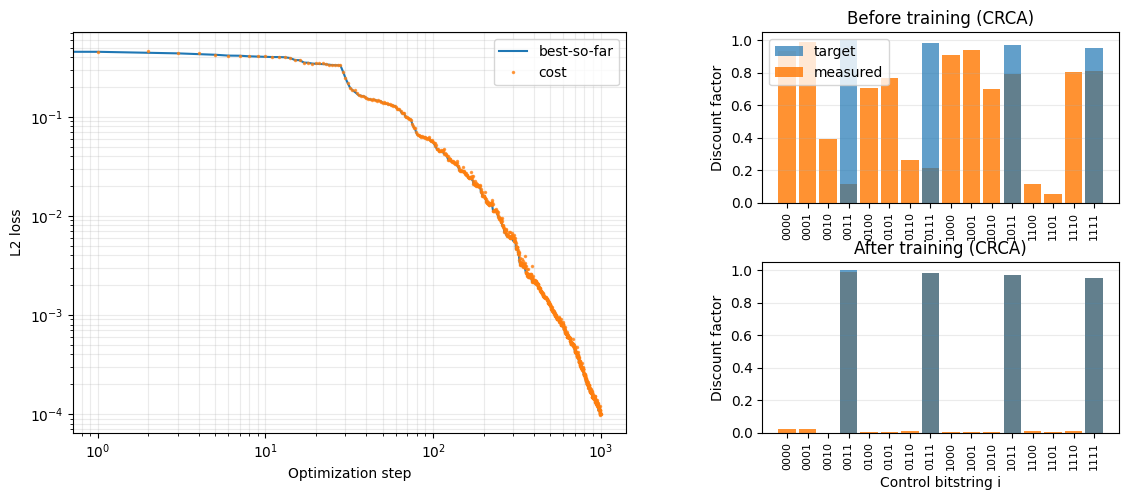

In [9]:
theta_star = np.asarray(res.x, dtype=float)

# 2) Recompute before/after function values
f0 = crca.function_values(x0, shots=None)
f_star = crca.function_values(theta_star, shots=None)

# 3) best-so-far curve and indices
best_so_far = np.minimum.accumulate(cost_history)
tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

# 4) Labels (bitstrings of length n_controls)
labels = [format(i, f"0{crca.n_controls}b") for i in range(crca.dim_controls)]

plot_training_diagnostics(
    target=positive_exposure_target,
    before=f0,
    after=f_star,
    cost_history=cost_history,
    best_so_far=best_so_far,
    best_idx=best_idx,
    labels=labels,
    xlabel="Control bitstring i",
    ylabel="Discount factor",
    cost_ylabel="L2 loss",
    title_before="Before training (CRCA)",
    title_after="After training (CRCA)",
    cost_log_x=True,
    cost_log_y=True
)

2. Shots-based setting

In [11]:
cv = SPSAHyperparamCV(
    x0=x0,
    lr_grid=[0.01, 0.02, 0.04, 0.06, 0.10, 0.15, 0.20],
    pert_grid=[0.05, 0.08, 0.12, 0.18, 0.25, 0.35],
    eps_grid=None,                 # <- sin epsilon
    shots_train=2000,
    shots_eval=8000,
    cv_iters=250,
    top_k=5,
    cv_iters_fine=400,
    trust_region=True,
    verbose=True,
)

res = cv.fit(
    make_cost_train=lambda shots, eps: crca.cost_fn(positive_exposure_target, shots=shots, seed=None),
    make_cost_eval =lambda shots, eps: crca.cost_fn(positive_exposure_target, shots=shots, seed=None),
)

best_lr, best_pert = res.best_lr, res.best_pert
print("Best hyperparameters found by CV:")
print("  lr   =", best_lr)
print("  pert =", best_pert)
print(" Best cost =", res.best_cost)

[coarse] lr=0.0100, pert=0.0500 -> eval=3.038e-01
[coarse] lr=0.0100, pert=0.0800 -> eval=3.108e-01
[coarse] lr=0.0100, pert=0.1200 -> eval=3.149e-01
[coarse] lr=0.0100, pert=0.1800 -> eval=3.043e-01
[coarse] lr=0.0100, pert=0.2500 -> eval=3.026e-01
[coarse] lr=0.0100, pert=0.3500 -> eval=3.332e-01
[coarse] lr=0.0200, pert=0.0500 -> eval=1.792e-01
[coarse] lr=0.0200, pert=0.0800 -> eval=1.919e-01
[coarse] lr=0.0200, pert=0.1200 -> eval=1.902e-01
[coarse] lr=0.0200, pert=0.1800 -> eval=1.943e-01
[coarse] lr=0.0200, pert=0.2500 -> eval=1.859e-01
[coarse] lr=0.0200, pert=0.3500 -> eval=1.997e-01
[coarse] lr=0.0400, pert=0.0500 -> eval=1.239e-01
[coarse] lr=0.0400, pert=0.0800 -> eval=1.082e-01
[coarse] lr=0.0400, pert=0.1200 -> eval=9.684e-02
[coarse] lr=0.0400, pert=0.1800 -> eval=1.123e-01
[coarse] lr=0.0400, pert=0.2500 -> eval=1.035e-01
[coarse] lr=0.0400, pert=0.3500 -> eval=1.177e-01
[coarse] lr=0.0600, pert=0.0500 -> eval=7.762e-02
[coarse] lr=0.0600, pert=0.0800 -> eval=6.465e-02


C:\Users\guilb\Desktop\Quantum-CVA\src\quantum_cva\circuit_training_tools.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


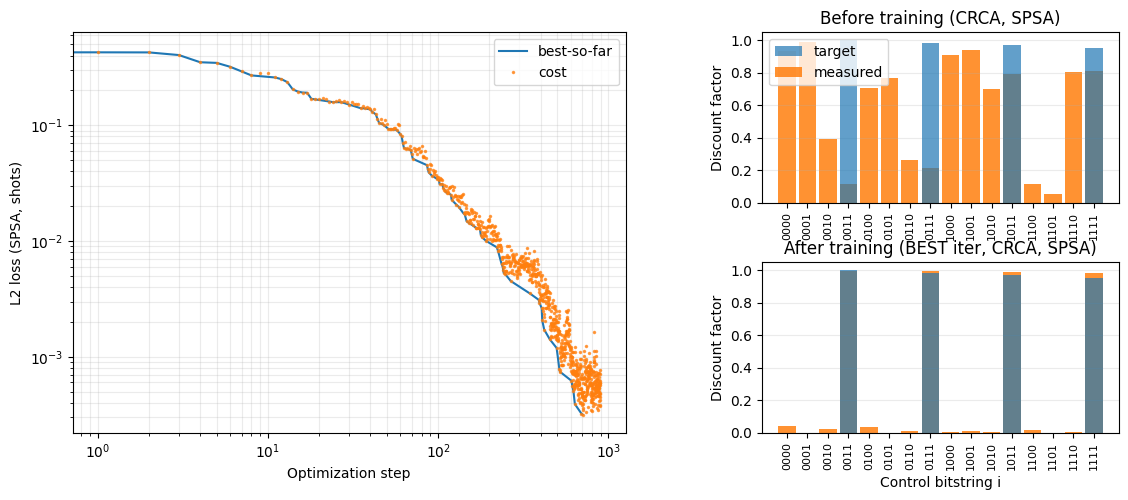

In [13]:
# =========================
# Shot-based training for CRCA with SPSA 
# =========================
N_ITERS = 900
SHOTS = 5000

# fixed-shot objective
cost_shots = crca.cost_fn(positive_exposure_target, shots=SHOTS, seed=None)

cost_history: list[float] = []

# guardar mejor
best = {
    "fx": float("inf"),
    "x": np.asarray(x0, dtype=float).copy(),
}

def spsa_cb(nfev, x, fx, stepsize, accepted):
    fx = float(fx)
    cost_history.append(fx)
    if fx < best["fx"]:
        best["fx"] = fx
        best["x"] = np.asarray(x, dtype=float).copy()

# -------------------------
# SPSA setup
# -------------------------
opt = SPSA(
    maxiter=int(N_ITERS),
    learning_rate=best_lr,
    perturbation=best_pert,
    blocking=False,
    trust_region=True,
    callback=spsa_cb,
)

# -------------------------
# Run optimization
# -------------------------
res = opt.minimize(fun=cost_shots, x0=x0)

theta_last = np.asarray(res.x, dtype=float)
theta_best = best["x"].copy()

# -------------------------
# Diagnostics (BEST iteration)
# -------------------------
f_star_best = crca.function_values(theta_best, shots=SHOTS, seed=None)

# -------------------------
# Cost history + best-so-far
# -------------------------
cost_history = np.asarray(cost_history, dtype=float)
best_so_far = np.minimum.accumulate(cost_history)
tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

labels = [format(i, f"0{crca.n_controls}b") for i in range(crca.dim_controls)]

plot_training_diagnostics(
    target=positive_exposure_target,
    before=f0,
    after=f_star_best,   
    cost_history=cost_history,
    best_so_far=best_so_far,
    best_idx=best_idx,
    labels=labels,
    xlabel="Control bitstring i",
    ylabel="Discount factor",
    cost_ylabel="L2 loss (SPSA, shots)",
    title_before="Before training (CRCA, SPSA)",
    title_after="After training (BEST iter, CRCA, SPSA)",
    cost_log_x=True,
    cost_log_y=True,
)

Save data

In [ ]:
optimizer_hparams = {
    "optimizer": "SPSA",
    "optimizer_library": "qiskit-algorithms",

    "learning_rate": float(best_lr),
    "perturbation": float(best_pert),
    "maxiter": int(N_ITERS),
    "resamplings": 1,              
    "blocking": False,
    "trust_region": True,

    "hyperparam_selection": "SPSA coarse+refined grid (CV via eval objective)",
}

best_run_info = {
    "best_iter_cost_observed": float(best.get("fx", np.nan)),
}

OUTDIR = Path("../../../data/crca/positive_exposures")

npz_path, json_path = save_crca_training(
    f_trained=f_star,                          # shot-based trained (choose best or last consistently)
    f_statevector=f_star_statevector,          # ideal result
    f_target=positive_exposure_target,
    filename_stem="crca_psotive_exposure_spsa_shots",
    outdir=OUTDIR,
    metadata={
        # --- Model identity ---
        "model": "CRCA",
        "task": "positive_exposure",
        "ancilla_observable": "P(a=1 | control=i, j)",

        # --- Circuit structure ---
        "m_time": crca.m_time,
        "n_price": crca.n_price,
        "n_controls": crca.n_controls,
        "n_layers": crca.n_layers,
        "n_parameters": crca.n_params,

        # --- Optimizer / hyperparams (best from CV) ---
        **optimizer_hparams,

        # --- Run-specific diagnostics (optional) ---
        **best_run_info,

        # --- Objective / noise model ---
        "cost_function": "L2",
        "shots": int(SHOTS),
        "stochastic_cost": True,
        "shot_seed": None,

        # --- Ideal reference ---
        "statevector_reference": True,

        # --- Run semantics ---
        "stopping_criterion": "maxiter",
        "note": (
            "CRCA positive-exposure training. "
            "Hyperparams stored are the best selected by CV and then used in the final run."
        ),
    }
)